<!-- Notebook acadêmico — resolução de laboratório de Deep Learning. -->
<!-- Documentação: ../DOCUMENTACAO.md -->
> **Portfólio acadêmico:** saídas da última execução preservadas. Consulte o README para reprodução.


# Disciplina: Deep Learning
## Lab 04 - O Algoritmo de Backpropagation e Otimização

**Orientações para o Aluno:**
- Leia atentamente cada enunciado antes de prosseguir.
- Este laboratório explora a implementação manual e automática do ajuste de pesos em redes neurais.
- Certifique-se de executar as células de importação iniciais antes de resolver os exercícios.
- O gabarito está incluso para conferência, mas tente resolver sozinho primeiro!

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# Configuração para reprodutibilidade
np.random.seed(42)
torch.manual_seed(42)

### 🔹 Questão 1: Regra da Cadeia e Derivação Manual
**Enunciado:** O Backpropagation é fundamentado na Regra da Cadeia. Considere uma função composta $f(x) = (w · x + b)^2$. Calcule a derivada de $f$ em relação a $w$ utilizando a regra da cadeia e implemente uma função em Python que calcule esse gradiente manualmente.

**Requisitos:**
- Definir a função `manual_gradient(x, w, b)`.
- Retornar o valor da derivada $\frac{\partial f}{\partial w}$.

In [3]:
def manual_gradient(x, w, b):
    # f = u^2, onde u = w*x + b
    # df/dw = df/du * du/dw
    # df/du = 2*u | du/dw = x
    u = w * x + b
    df_dw = 2 * u * x # Aplicação da regra da cadeia
    return df_dw

# Teste
x, w, b = 2.0, 0.5, 1.0
grad = manual_gradient(x, w, b)
print(f"Gradiente manual calculado: {grad}")

Gradiente manual calculado: 8.0


### 🔹 Questão 2: Computational Graph com PyTorch (Autograd)
**Enunciado:** Redes neurais complexas tornam o cálculo manual inviável. Utilize o motor `Autograd` do PyTorch para calcular o gradiente da mesma função da Questão 1 e compare os resultados.

**Requisitos:**
- Utilizar tensores com `requires_grad=True`.
- Executar o método `.backward()`.

In [4]:
# Definindo variáveis como tensores do PyTorch
x = torch.tensor(2.0)
w = torch.tensor(0.5, requires_grad=True) # Precisamos do gradiente para w
b = torch.tensor(1.0)

# Definindo a função
f = (w * x + b)**2

# Backpropagation automático
f.backward()

print(f"Gradiente via PyTorch (Autograd): {w.grad.item()}")
print(f"Os resultados coincidem? {np.isclose(w.grad.item(), grad)}")

Gradiente via PyTorch (Autograd): 8.0
Os resultados coincidem? True


### 🔹 Questão 3: Otimizadores e o Problema do Learning Rate
**Enunciado:** O otimizador (como SGD ou Adam) utiliza o gradiente para atualizar os pesos. Se o *learning rate* (taxa de aprendizado) for muito alto, o modelo pode divergir. Se for muito baixo, o treino será lento.
Implemente um loop simples de otimização para encontrar o valor de $w$ que minimiza a função $L(w) = w^2 - 4w + 4$ usando `optim.SGD`.

**Requisitos:**
- Tentar encontrar o mínimo global (que é $w=2$).
- Realizar 20 iterações de atualização.

Iniciando Otimização...

Valor final de w: 1.9885 (Esperado: 2.0)


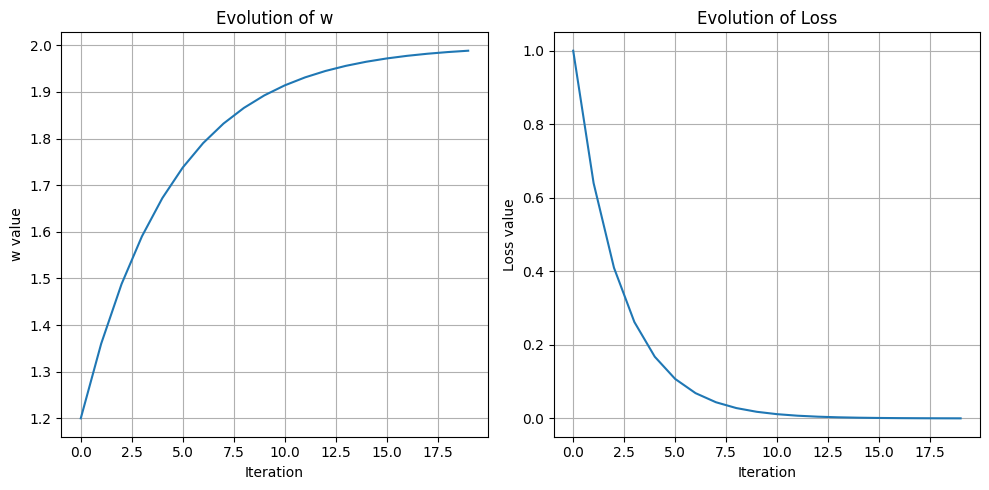

In [10]:
# Parâmetro inicial aleatório
w = torch.tensor([1.0], requires_grad=True)
learning_rate = 0.1
optimizer = optim.SGD([w], lr=learning_rate) # Otimizador Stochastic Gradient Descent

w_history = []
loss_history = []

print("Iniciando Otimização...")
for i in range(20):
    optimizer.zero_grad() # Limpa gradientes da iteração anterior
    loss = w**2 - 4*w + 4 # Nossa função de perda
    loss.backward() # Backpropagation: calcula o gradiente dLoss/dw
    optimizer.step() # Atualiza w: w = w - lr * grad

    w_history.append(w.item())
    loss_history.append(loss.item())


print(f"\nValor final de w: {w.item():.4f} (Esperado: 2.0)")

# Plotting the results
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(w_history)
plt.title('Evolution of w')
plt.xlabel('Iteration')
plt.ylabel('w value')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.title('Evolution of Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss value')
plt.grid(True)

plt.tight_layout()
plt.show()

### 🔹 Questão 4: Comparação de Otimizadores (Momentum vs Adam)
**Enunciado:** O slide discute como o Momentum e o Adam ajudam a superar mínimos locais e platôs. Crie um pequeno código para treinar um modelo linear simples com `torch.nn.Linear` e compare o comportamento da perda entre o `SGD` puro e o `Adam`.

**Requisitos:**
- Criar dados sintéticos ($y = 3x + 1$).
- Comparar visualmente a descida da perda.

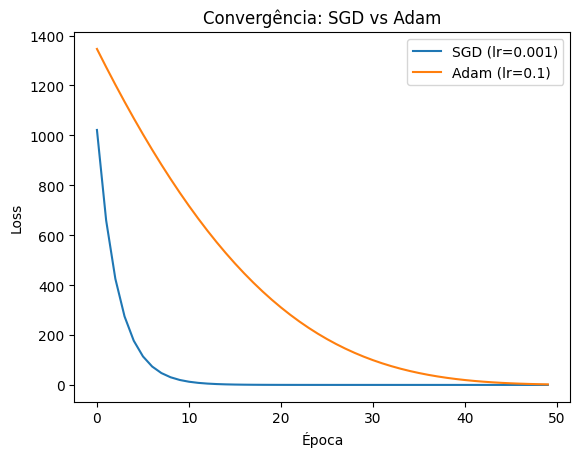

In [25]:
# 1. Dados sintéticos
X = torch.randn(100, 1) * 10
y = 3 * X + 1 + torch.randn(100, 1) # y = 3x + 1 + ruído

def train_model(opt_name):
    model = nn.Linear(1, 1)
    criterion = nn.MSELoss()
    if opt_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.001)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.1)

    losses = []
    for _ in range(50):
        pred = model(X)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

# Treinamento
loss_sgd = train_model('SGD')
loss_adam = train_model('Adam')

# Visualização
plt.plot(loss_sgd, label='SGD (lr=0.001)')
plt.plot(loss_adam, label='Adam (lr=0.1)')
plt.title('Convergência: SGD vs Adam')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show() # Adam costuma convergir muito mais rápido em problemas simples